<a href="https://colab.research.google.com/github/tomsBifx25/Mus-Glioblastoma-snRNAseq/blob/main/notebooks/Test_pipeV01_runs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

New notebook with different approach

# **Predicting Malignant vs. Microenvironment Identity in Glioblastoma via Single-Nucleus Transcriptomics.**
****
*Thomas Walsh | March 18, 2026*

**Hood College**
*   Machine Learning for Bioinformatics (BIFX 546), Spring 2026
*   Instructor: Dr. Sarangan (Ravi) Ravichandran
****
**Dataset**

* Name: longevity-db/mouse-glioblastoma-snRNAseq

* Source: https://huggingface.co/datasets/longevity-db/mouse-glioblastoma-snRNAseq | CELLxGENE | GEO: GSE186252
****
**Project Goals**

Can we predict whether a cell belongs to the tumor core vs. the tumor microenvironment using transcriptomic summary features and QC-derived metrics?

While much research focuses on the tumor's genetic mutations, the tumor microenvironment (TME) remains under-explored. This dataset is unique because it provides single-nucleus RNA sequencing (snRNA-seq) across many cell types and from the tumor core itself and the surrounding microenvironment. This allows for a granular look at how the TME modulates cancer progression and immune evasion. The TME is a risk factor for multiple cancer types, in this dataset, the cancer type of the samples used was glioblastoma (GBM).

# Overview
##  1. Setup
##  2. Data Loading
##  3. Quality Control
##  4. Summary Statistics
##  5. Dimensionality Reduction
##  6. Clustering
##  7. Modeling
##  8. Interpretation
##  9. Next Steps
## 10. Acknowledgements

## 1. Setup

In [2]:
pip install datasets

In [3]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

## 2. Data Loading, 10k Samples

In [4]:
from datasets import load_dataset
import pandas as pd

dataset_name = "longevity-db/mouse-glioblastoma-snRNAseq"

streamed_dataset = load_dataset(dataset_name, streaming=True)

sample_size = 10000
sampled_data = []

for i, example in enumerate(streamed_dataset['train']):
    if i >= sample_size:
        break
    sampled_data.append(example)

df = pd.DataFrame(sampled_data)

print(df.shape)
df.head()

README.md: 0.00B [00:00, ?B/s]

(10000, 29)


,nCount_RNA,nFeature_RNA,sub_celltype,assay_ontology_term_id,organism_ontology_term_id,development_stage_ontology_term_id,disease_ontology_term_id,is_primary_data,self_reported_ethnicity_ontology_term_id,sex_ontology_term_id,...,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,n_genes,cell_id
0,1113.0,591,Astrocyte,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,UrkBeMgX@4,588,3920-19_AAACCCACAAACACCT-1
1,1417.0,755,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,@x{bDyo8WK,754,3920-19_AAACCCAGTCCAACGC-1
2,8532.0,3448,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,za~S?77j{3,3441,3920-19_AAACCCAGTGCGTTTA-1
3,8987.0,3554,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,jm43>$?2c0,3546,3920-19_AAACCCAGTGGATACG-1
4,1669.0,951,Tumor,EFO:0009922,NCBITaxon:10090,MmusDv:0000062,MONDO:0018177,True,na,PATO:0000383,...,10x 3' v3,glioblastoma,Mus musculus,female,brain,na,2-month-old stage,Y^c3RkVgoa,946,3920-19_AAACCCATCCTATTGT-1


## 3. Quality Control
### Quality check
* Make sure to check for low counts and reads to eliminate bad samples

In [5]:
# Standard single-cell QC filters
df = df[
    (df["nFeature_RNA"] > 200) &
    (df["nCount_RNA"] > 500)
].copy()

print("After QC:", df.shape)

After QC: (10000, 29)


### Classification
* redefine target variable to distinguish between tumor and non-tumor

In [6]:
# Binary classification: tumor vs microenvironment
df["target"] = df["sub_celltype"].apply(
    lambda x: "tumor" if "tumor" in str(x).lower() else "non_tumor"
)

df["target"].value_counts()

,count
target,
tumor,6331
non_tumor,3669


### Exploratory Data Analysis (EDA)

distrubution plots

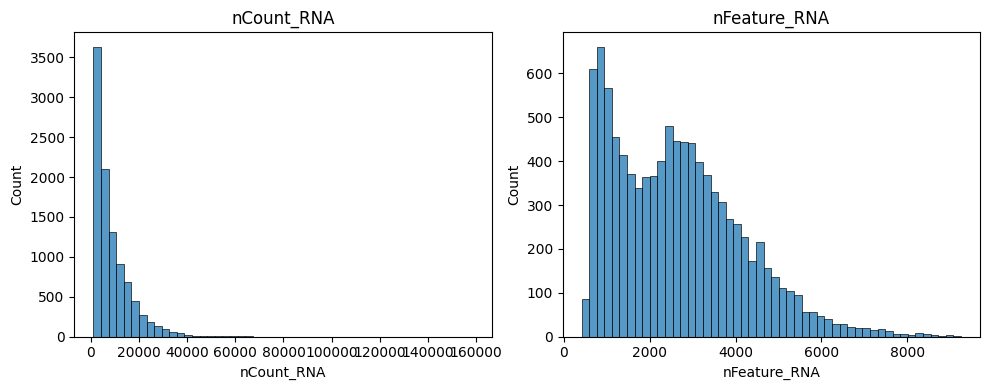

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(df["nCount_RNA"], bins=50, ax=axes[0])
axes[0].set_title("nCount_RNA")

sns.histplot(df["nFeature_RNA"], bins=50, ax=axes[1])
axes[1].set_title("nFeature_RNA")

plt.tight_layout()
plt.show()

Cell Type Proportions

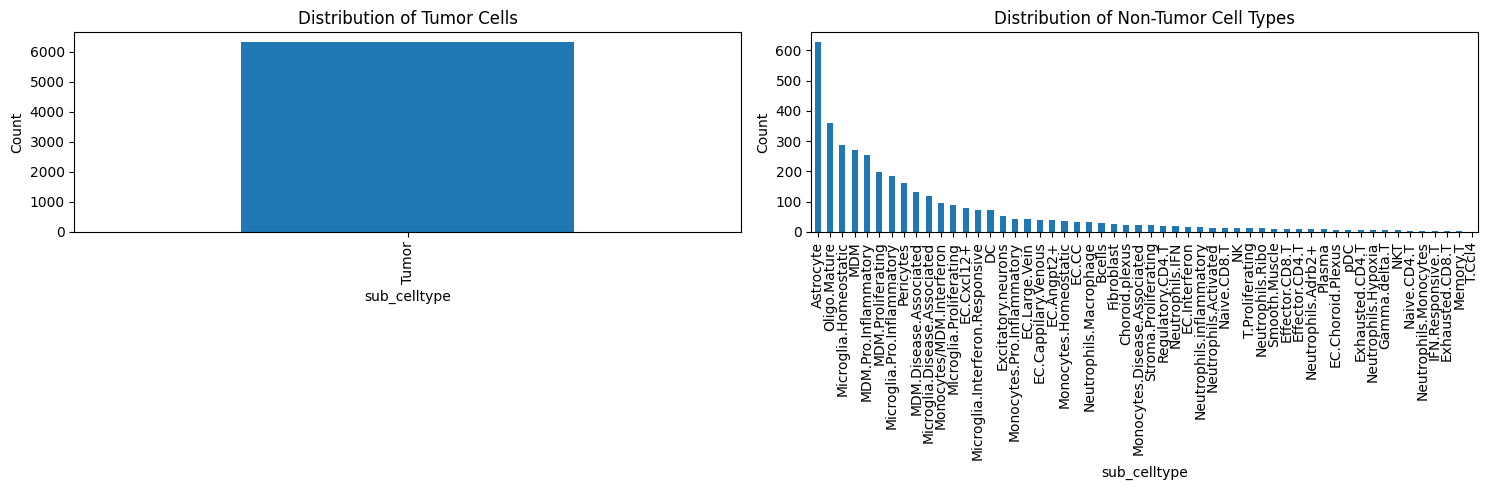

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot for Tumor category
df[df['target'] == 'tumor']['sub_celltype'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribution of Tumor Cells')
axes[0].set_ylabel('Count')

# Plot for all other cell types
df[df['target'] == 'non_tumor']['sub_celltype'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Distribution of Non-Tumor Cell Types')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Target Balance

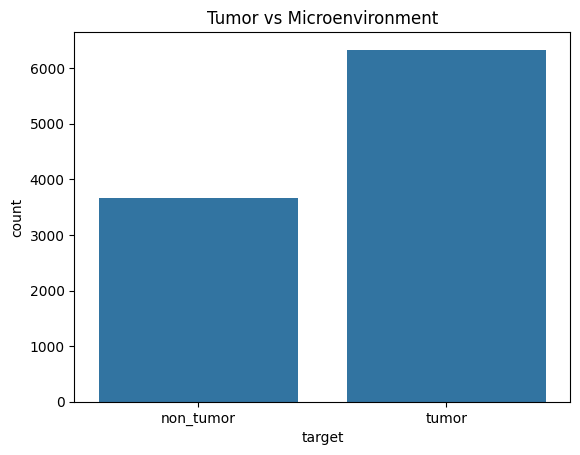

In [9]:
sns.countplot(x="target", data=df)
plt.title("Tumor vs Microenvironment")
plt.show()

### Normalization

In [10]:
import numpy as np

# Normalize counts per cell
df["nCount_RNA_norm"] = df["nCount_RNA"] / df["nCount_RNA"].sum() * 1e4
df["nCount_RNA_log"] = np.log1p(df["nCount_RNA_norm"])

df["nFeature_RNA_log"] = np.log1p(df["nFeature_RNA"])

## 4. Summary Statistics


In [11]:
# Summary Stats table for the 10k dataset
df.describe().drop('count')

,nCount_RNA,nFeature_RNA,n_genes,nCount_RNA_norm,nCount_RNA_log,nFeature_RNA_log
mean,8834.556200,2639.601000,2633.546200,1.000000,0.601723,7.698105
std,9370.573313,1505.242457,1502.804753,1.060673,0.398570,0.631402
min,1001.000000,411.000000,409.000000,0.113305,0.107333,6.021023
25%,2656.750000,1343.000000,1338.750000,0.300723,0.262920,7.203406
50%,6113.000000,2486.500000,2481.500000,0.691942,0.525877,7.819033
75%,11969.250000,3573.000000,3566.250000,1.354822,0.856465,8.181441
max,158702.000000,9253.000000,9236.000000,17.963777,2.942531,9.132811


## 5. Dimensionality Reduction
### PCA + UMAP

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

features = [
    "nCount_RNA_log",
    "nFeature_RNA_log"
]

X = df[features]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# UMAP
umap_model = umap.UMAP(random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


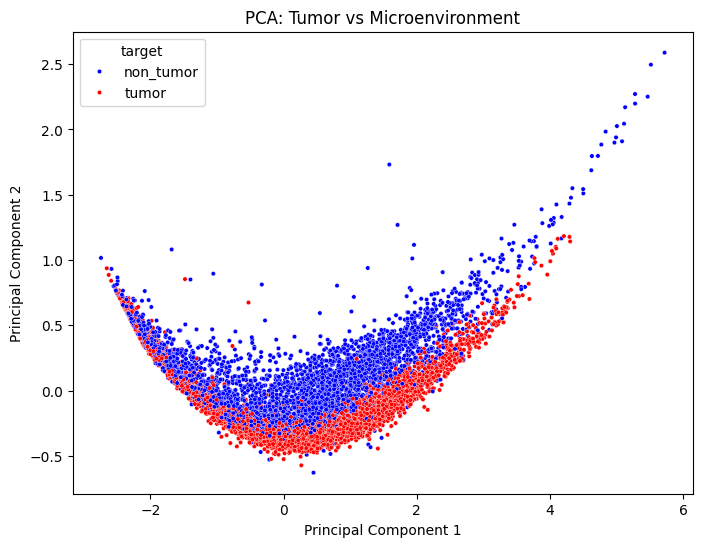

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["target"],
    palette={"tumor":"red","non_tumor":"blue"},
    s=10
)

plt.title("PCA: Tumor vs Microenvironment")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

UMAP

By Cell Type

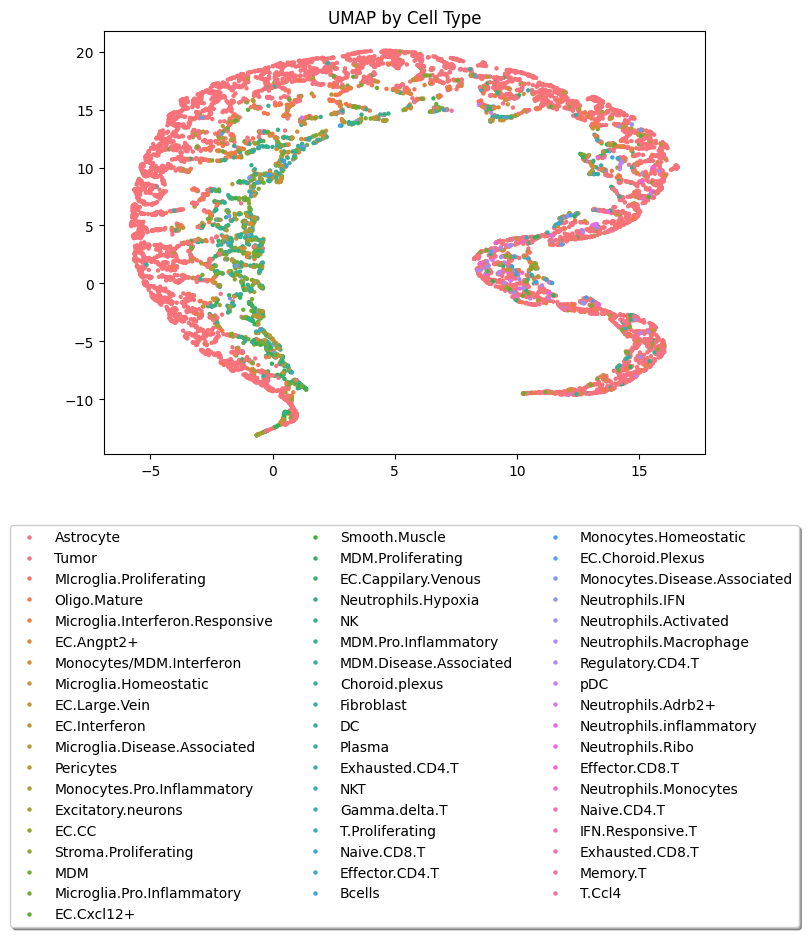

In [14]:
plt.figure(figsize=(8,10))

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=df["sub_celltype"],
    s=10,
    linewidth=0
)

plt.title("UMAP by Cell Type")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=3)
plt.tight_layout()
plt.show()

By Tumor vs Microenvironment

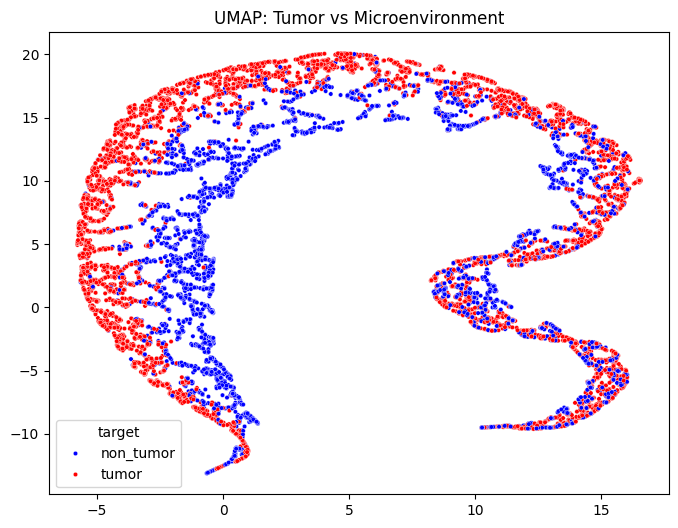

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=df["target"],
    palette={"tumor":"red","non_tumor":"blue"},
    s=10
)

plt.title("UMAP: Tumor vs Microenvironment")
plt.show()

## 6. Clustering
### K means clustering from log-transformed counts and reads

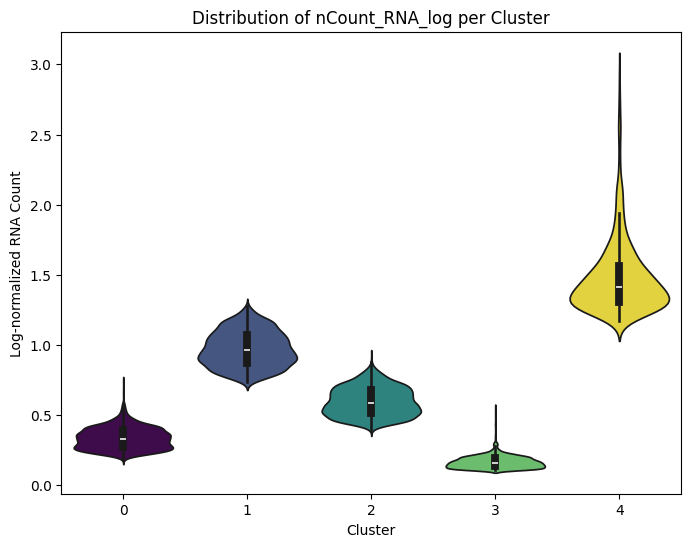

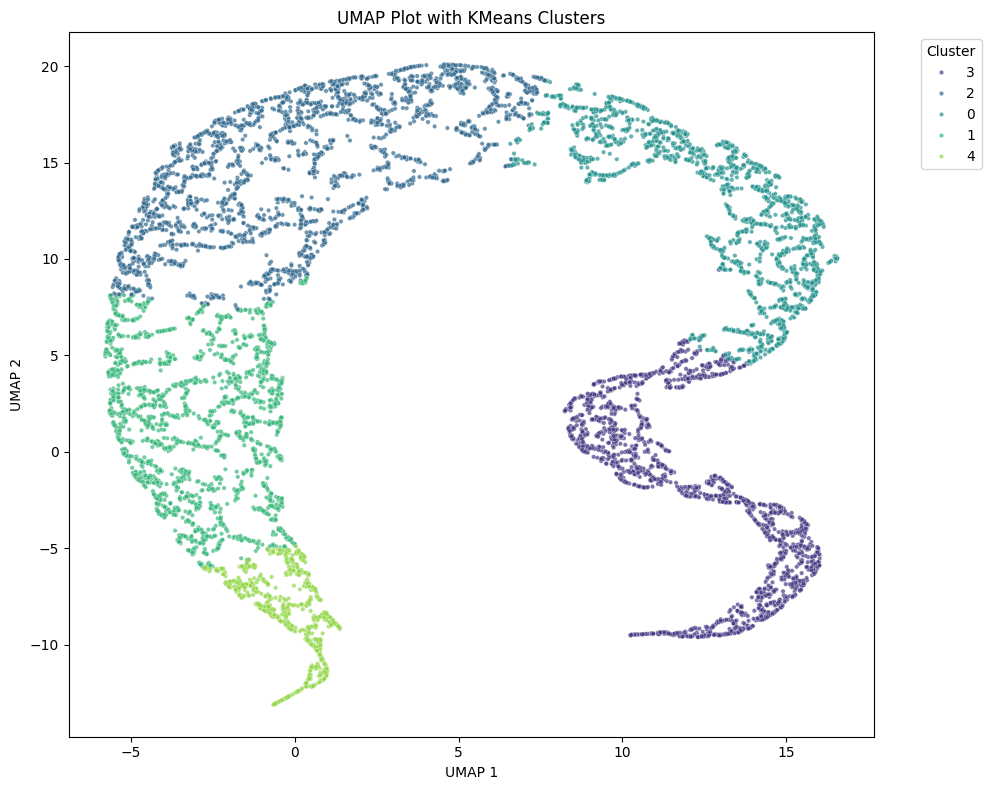

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# K means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
df["cluster"] = kmeans.fit_predict(X_scaled)

# Violin plot of cluster sizes
plt.figure(figsize=(8, 6))
sns.violinplot(x="cluster", y="nCount_RNA_log", data=df, palette='viridis', hue="cluster", legend=False)
plt.title("Distribution of nCount_RNA_log per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Log-normalized RNA Count")
plt.show()

# Visualization of clusters with UMAP
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=df["cluster"].astype(str), # Convert to string for discrete colors
    palette='viridis',
    s=10,
    alpha=0.7
)

# Figure labels
plt.title("UMAP Plot with KMeans Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
pd.crosstab(df["cluster"], df["target"])

target,non_tumor,tumor
cluster,,
0,653,1406
1,1066,1091
2,911,1954
3,591,1546
4,448,334


### Cluster Interpretation

The K-Means clustering, visualized on the UMAP plot, shows a reasonable separation of data points into 5 clusters. The violin plot provides insights into the distribution of `nCount_RNA_log` within each cluster, indicating differences in gene expression levels or cell sizes across clusters.

The crosstabulation of `cluster` against the `target` variable (`tumor` vs `non_tumor`) reveals how these computationally derived clusters relate to the biological classification. For example:

*   **Cluster 0** has a higher proportion of 'tumor' cells compared to 'non_tumor' cells (1406 vs 653).
*   **Cluster 1 and 2** also show a substantial number of tumor cells, with Cluster 2 having the highest number of tumor cells (1954).
*   **Cluster 4** appears to have a more balanced distribution or even a slight majority of 'non_tumor' cells (448 vs 334), suggesting it might represent the microenvironment or specific non-tumor cell types.

This suggests that while the clustering based on `nCount_RNA_log` and `nFeature_RNA_log` doesn't perfectly separate tumor from non-tumor cells, it does capture underlying cellular characteristics that correlate with the target variable to some extent. Further analysis could explore the specific cell types within each cluster and their biological significance.

## 7. Modeling
### Training and Testing

In [18]:
from sklearn.model_selection import train_test_split

y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Random Forest Model & Decision trees

Accuracy: 0.856
              precision    recall  f1-score   support

   non_tumor       0.85      0.73      0.79       734
       tumor       0.86      0.93      0.89      1266

    accuracy                           0.86      2000
   macro avg       0.86      0.83      0.84      2000
weighted avg       0.86      0.86      0.85      2000



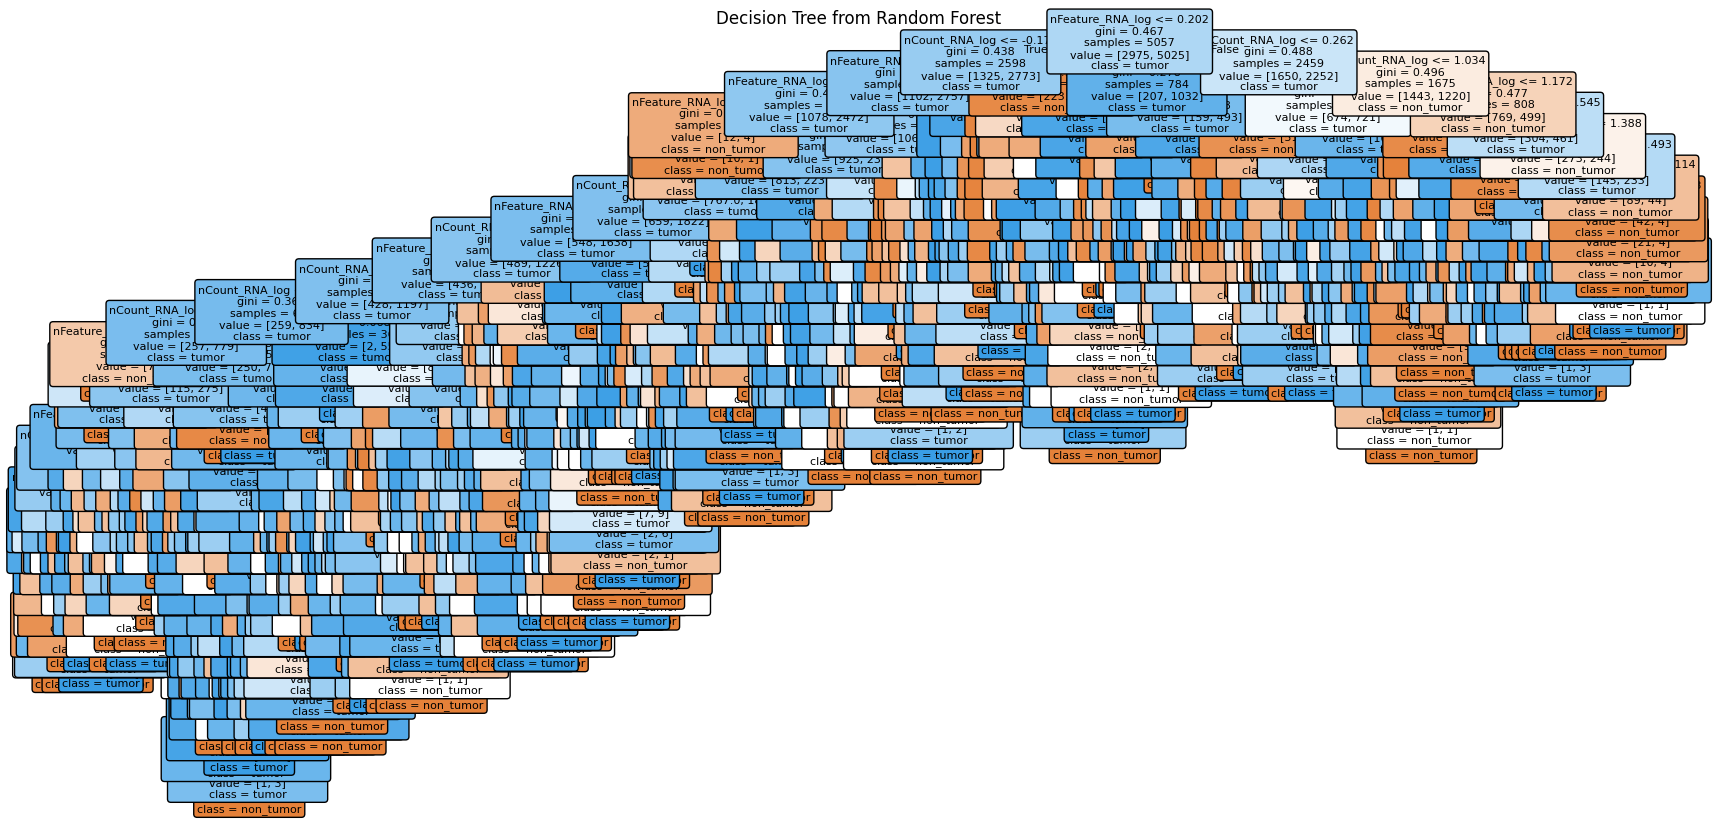

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Visualize one of the decision trees from the Random Forest
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0],
          feature_names=features,
          class_names=rf.classes_, # Use classes from the model
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree from Random Forest")
plt.show()

### Feature Importance

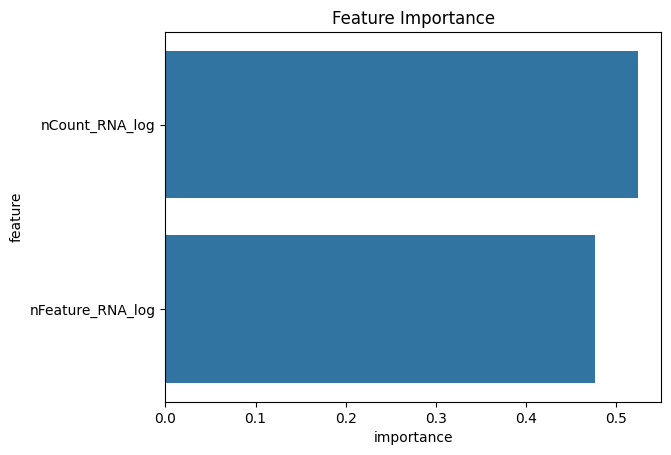

In [20]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Feature Importance")
plt.show()

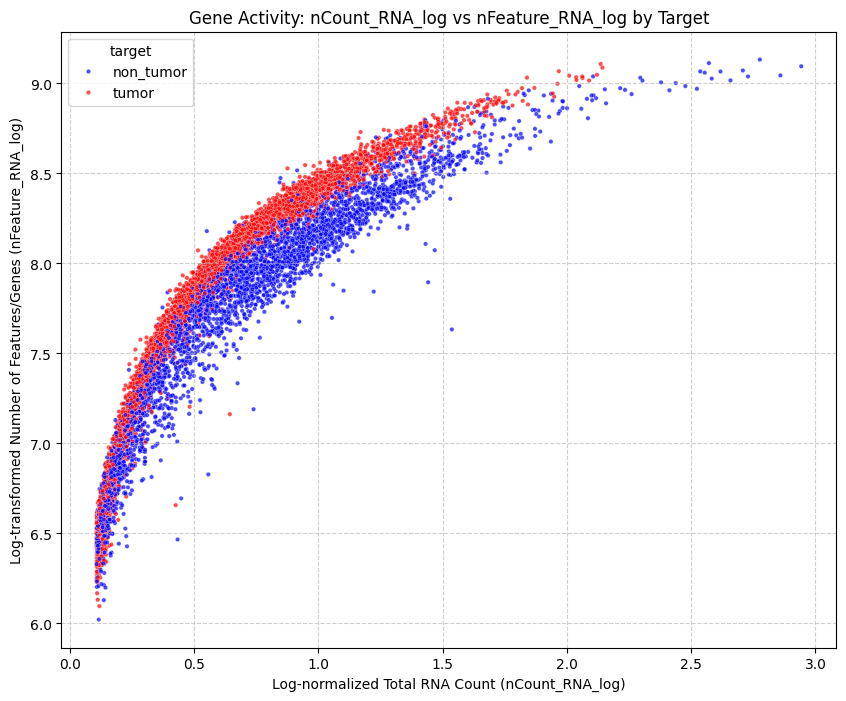

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='nCount_RNA_log',
    y='nFeature_RNA_log',
    hue='target',
    data=df,
    palette={'tumor': 'red', 'non_tumor': 'blue'},
    s=10, alpha=0.7
)

plt.title('Gene Activity: nCount_RNA_log vs nFeature_RNA_log by Target')
plt.xlabel('Log-normalized Total RNA Count (nCount_RNA_log)')
plt.ylabel('Log-transformed Number of Features/Genes (nFeature_RNA_log)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Relation to `n_genes` Feature

The `n_genes` column in your original DataFrame (`df`) represents the raw count of unique genes detected in each cell. In our data processing steps (specifically in cell `M6BQqTp_EJgT`), this `n_genes` feature was log-transformed to create `nFeature_RNA_log`.

The scatter plot above directly uses this `nFeature_RNA_log` on its y-axis. Therefore, the plot is indeed utilizing your `n_genes` metric (in its log-transformed form) to visualize gene activity. It shows how the number of detected genes (and total RNA counts) vary between tumor and non-tumor cells, providing insights into their distinct transcriptional profiles. The log transformation helps to normalize the data distribution and reduce the impact of outliers, which is beneficial for both visualization and subsequent modeling.